In [208]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import json
from scipy import interpolate
from skimage import io
import imageio.v3 as iio



In [209]:
def load_image(image_path):
    """
    Loads an image from a given file path.

    Args:
        image_path (str): The complete path to the image file.

    Returns:
        numpy.ndarray: The loaded image as an array of pixels.
    """
    image = io.imread(image_path)
    return image

In [210]:
def load_json(file_path):
    """
    Loads a JSON file and returns its content.

    Args:
        file_path (str): The path to the JSON file.

    Returns:
        list/dict: The parsed JSON data.
    """
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)
    
    return data

In [211]:
def get_defect_coordinates(json_data, image_number):
    """
    Parses JSON data to extract defect coordinates for a specific image number.

    Args:
        json_data (list): The list of dictionaries loaded from the JSON file.
        image_number (str or int): The specific image number to look for in the JSON.

    Returns:
        dict: A dictionary where keys are x-coordinates (columns) and values 
              are dictionaries containing lists of 'start' and 'stop' y-coordinates.
    """
    defect_dict = {}
    
    for item in json_data:
        value = item.get('signal', {}).get(str(image_number))
        
        if value is not None:
            for x_coord in item.get('x_coord', []):
                
                defect_dict[x_coord] = {
                    'start': item.get('y_start', []), 
                    'stop': item.get('y_stop', [])
                }

    return defect_dict

In [212]:
def normalize_to_8bit(image_array):
    """
    Normalizes an image array (e.g., 16-bit) to an 8-bit range (0 to 255).

    Args:
        image_array (numpy.ndarray): The input image array.

    Returns:
        numpy.ndarray: The normalized image array with dtype uint8.
    """
    img_np = np.array(image_array, dtype=np.float32)
    
    val_min = np.min(img_np)
    val_max = np.max(img_np)
    
    if val_max == val_min:
        return np.zeros_like(img_np, dtype=np.uint8)
        
    normalized_image = ((img_np - val_min) / (val_max - val_min)) * 255
    
    return normalized_image.astype(np.uint8)

In [213]:
# def normalize_to_8bit(image_array):
#     """""
#     Convert 16 bits img into 8 bits using percentiles to not be biased by outliers  
#     arg : img 
#     return : converted img in 8 bits
#     """""
#     p2, p98 = np.percentile(image_array, (2, 98))
#     img_clipped = np.clip(image_array, p2, p98)
    
#     # 2. Normaliser entre 0 et 255
#     normalized_image = ((img_clipped - p2) / (p98 - p2) * 255).astype(np.uint8)
#     return normalized_image

In [214]:
def get_automated_paths_and_number(image_path):
    """
    Extracts the frame number from the image filename and automatically 
    locates the companion JSON config file within the same directory.

    Args:
        image_path (str): The complete path to the image file.

    Returns:
        tuple: (int: image_number, str: json_path)
    """
    image_dir = os.path.dirname(image_path)
    file_name = os.path.basename(image_path)
    
    # Extract image sequence number 
    try:
        number_string = file_name.split('_')[1].split('.')[0]
        image_number = int(number_string)
    except (IndexError, ValueError):
        raise ValueError(f"Could not parse image number from filename: {file_name}. Expected format: prefix_0000.png")
        
    # Automatically locate the JSON file in the same directory
    json_files = glob.glob(os.path.join(image_dir, "*.json"))
    if not json_files:
        raise FileNotFoundError(f"No JSON configuration file found in: {image_dir}")
        
    json_path = json_files[0]
    
    return image_number, json_path


In [215]:
# def interpolate_inside_stripe(mat, list_mask, kind="linear"):
#     """
#     Interpolate gray-scales inside vertical stripes of an image. Stripe
#     locations given by a binary 1D-mask.

#     Args: 
#         mat : array_like 2D array.
#         list_mask : array_like 1D array. Must equal the width of an image.
#         kind : {'linear', 'cubic', 'quintic'}, optional
#             The kind of spline interpolation to use. Default is 'linear'.

#     Returns:
#         array_like
#     """
#     (nrow, ncol) = mat.shape
#     if len(list_mask) != ncol:
#         raise ValueError("Length of a binary 1D-mask is not the same as the "
#                          "width of an image!")
#     mat = np.copy(mat)
#     list_mask = np.copy(list_mask)
#     list_mask[0:2] = 0.0
#     list_mask[-2:] = 0.0
#     xlist = np.where(list_mask < 1.0)[0]
#     ylist = np.arange(nrow)
#     if kind == "cubic":
#         finter = interpolate.RectBivariateSpline(ylist, xlist, mat[:, xlist],
#                                                  kx=2, ky=2)
#     elif kind == "quintic":
#         finter = interpolate.RectBivariateSpline(ylist, xlist, mat[:, xlist],
#                                                  kx=3, ky=3)
#     else:
#         finter = interpolate.RectBivariateSpline(ylist, xlist, mat[:, xlist],
#                                                  kx=1, ky=1)
#     xlist_miss = np.where(list_mask > 0.0)[0]
#     if len(xlist_miss) > 0:
#         x_mat_miss, y_mat = np.meshgrid(xlist_miss, ylist)
#         output = finter.ev(np.ndarray.flatten(y_mat),
#                            np.ndarray.flatten(x_mat_miss))
#         mat[:, xlist_miss] = output.reshape(x_mat_miss.shape)
#     return mat

In [216]:
import numpy as np
from scipy import interpolate

def interpolate_inside_stripe_optimized(mat, list_mask):
    """
    Hàm nội suy tối ưu hóa tự động dựa trên độ phân giải ảnh (VGA, HD, SXGA)
    """
    nrow, ncol = mat.shape
    total_pixels = nrow * ncol

    if len(list_mask) != ncol:
        raise ValueError("Length of a binary 1D-mask is not the same as the width of an image!")

    # --- Bước 1: Tự động quyết định 'kind' dựa trên độ phân giải ---
    # VGA: ~307k pixels -> Ưu tiên chất lượng (Cubic)
    # HD: ~921k pixels -> Cân bằng (Linear/Cubic tùy thuộc số stripe, chọn Linear cho an toàn)
    # SXGA: ~1.3M pixels -> Ưu tiên tốc độ tuyệt đối (Linear)
    if total_pixels <= 310000:
        kind = "cubic"       # kx=2, ky=2
    else:
        kind = "linear"      # kx=1, ky=1 (Tốc độ tối ưu cho HD/SXGA)

    # --- Bước 2: Tối ưu bộ nhớ (Tránh copy mảng nếu không cần thiết) ---
    mat = np.ascontiguousarray(mat) 
    list_mask = np.copy(list_mask)
    
    # Giới hạn biên an toàn của Algotom
    list_mask[0:2] = 0.0
    list_mask[-2:] = 0.0
    
    xlist = np.where(list_mask < 1.0)[0]
    ylist = np.arange(nrow)
    
    # Tìm các cột bị lỗi cần sửa
    xlist_miss = np.where(list_mask > 0.0)[0]
    if len(xlist_miss) == 0:
        return mat # Không có lỗi -> Trả về luôn, không tính toán phí phạm

    # --- Bước 3: Chỉ định bậc nội suy ---
    if kind == "cubic":
        kx, ky = 2, 2
    else:
        kx, ky = 1, 1 # Mặc định cho tuyến tính, cực nhanh cho SXGA

    # Khởi tạo nội suy Spline
    finter = interpolate.RectBivariateSpline(ylist, xlist, mat[:, xlist], kx=kx, ky=ky)
    
    # --- Bước 4: Tối ưu Meshgrid (Sử dụng sparse=True nếu cấu trúc cho phép để tiết kiệm RAM) ---
    x_mat_miss, y_mat = np.meshgrid(xlist_miss, ylist)
    
    # Đánh giá (evaluate) và ghi đè trực tiếp vào ma trận gốc
    output = finter.ev(y_mat.ravel(), x_mat_miss.ravel())
    mat[:, xlist_miss] = output.reshape(x_mat_miss.shape)
    
    return mat

In [217]:
def create_stripe_mask(defect_coordinates, image_width):
    """
    Converts defect coordinates dictionary into a 1D binary mask 
    required for the Algotom destriping function.

    Args:
        defect_coordinates (dict): Result from get_defect_coordinates.
        image_width (int): The width (ncol) of the 16-bit image.

    Returns:
        numpy.ndarray: 1D array of size (image_width,) where 1 represents a defective column.
    """
    list_mask = np.zeros(image_width, dtype=np.uint8)
    
    for x_coord in defect_coordinates.keys():
        x = int(x_coord)
        if 0 <= x < image_width:
            list_mask[x] = 1
            
    return list_mask

In [218]:
def display_comparison(original_image, processed_image):
    """
    Normalizes 16-bit images to 8-bit and plots them side-by-side for comparison.
    Uses the pre-existing normalize_to_8bit function.

    Args:
        original_image (numpy.ndarray): The raw original 16-bit image array.
        processed_image (numpy.ndarray): The destriped 16-bit image array.
    """
    # Scale both images to 8-bit strictly for rendering pipeline
    original_image_8bits = normalize_to_8bit(original_image)
    processed_image_8bits = normalize_to_8bit(processed_image)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Plot 1: The original corrupted image
    axes[0].imshow(original_image_8bits, cmap='gray')
    axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Plot 2: The destriped image processed by Algotom
    axes[1].imshow(processed_image_8bits, cmap='gray')
    axes[1].set_title("Corrected image", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [219]:
def get_automated_save_path(image_path):
    """
    Automatically constructs a save path inside a 'result_method_interpolation' subfolder 
    located in the same directory as the input image, keeping the original filename.

    Args:
        image_path (str): The complete path to the input image file.

    Returns:
        str: The absolute path to save the processed image.
    """
    # Tìm thư mục chứa ảnh gốc
    image_dir = os.path.dirname(image_path)
    
    # Lấy tên file ảnh gốc (ví dụ: "frame_0043.png")
    filename = os.path.basename(image_path)
    
    # ĐỔI TẠI ĐÂY: Tạo đường dẫn đến thư mục mới theo đúng ý bạn
    result_dir = os.path.join(image_dir, "result_method_interpolation")
    
    # Kết hợp lại thành đường dẫn file hoàn chỉnh
    automated_save_path = os.path.join(result_dir, filename)
    
    return automated_save_path

In [220]:
def pipeline_process_image(image_path, show_result=True):
    """
    Executes the complete processing block using isolated sub-functions.
    Calculates directly on the 16-bit native space and automatically saves the output.

    Args:
        image_path (str): The complete path to the input image file.
        show_result (bool): If True, displays the side-by-side comparison.

    Returns:
        numpy.ndarray: The pristine destriped 16-bit image array.
    """
    # Automatically detect frame number and JSON configuration path
    image_number, json_path = get_automated_paths_and_number(image_path)
    
    # Load original 16-bit image and JSON defect data 
    original_image = load_image(image_path)
    json_data = load_json(json_path)
    
    # Extract defect coordinates for the specific image number
    defect_coords = get_defect_coordinates(json_data, image_number)
    
    # Construct the 1D Mask array based on image width
    image_width = original_image.shape[1]
    list_mask = create_stripe_mask(defect_coords, image_width)
    
    # Use Algotom's cubic interpolation 
    corrected_image_16bit = interpolate_inside_stripe(original_image, list_mask)
    
    # Generate the automated save path (.../result_methodinterpolation/frame_XXXX.png)
    automated_save_path = get_automated_save_path(image_path)
    
    # Ensure the output directory exists, create it if missing
    output_dir = os.path.dirname(automated_save_path)
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created new directory file: {output_dir}")
        
    # Save the corrected image in 16-bit format 
    iio.imwrite(automated_save_path, corrected_image_16bit)
    print(f"Successfully saved image automatically to: {automated_save_path}")
    
    # Display
    if show_result:
        display_comparison(original_image, corrected_image_16bit)
        
    return corrected_image_16bit

Successfully saved image automatically to: /Users/thanhhiennguyenle/Documents/Data Challenge - Defective columns 2026/train/HD/sequence_1/low dyn with columns 2/result_method_interpolation/frame_0046.png


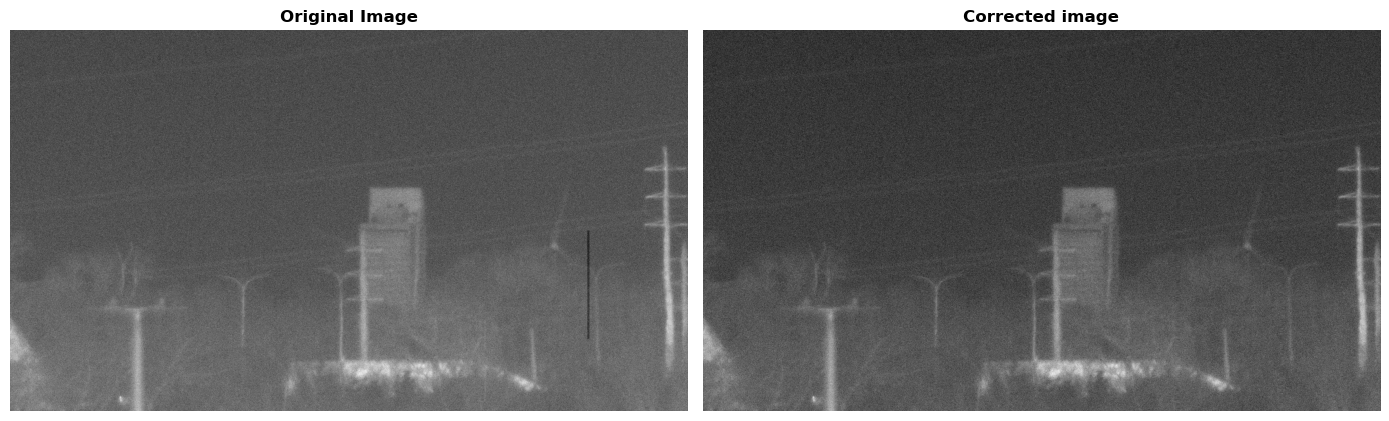

In [224]:
image_file = "/Users/thanhhiennguyenle/Documents/Data Challenge - Defective columns 2026/train/HD/sequence_1/low dyn with columns 2/frame_0046.png"

# Run the entire automated module pipeline
final_image_16bit = pipeline_process_image(image_file, show_result=True)